# AVD on a high-dimensional Roessler signal

This notebook builds a **high-dimensional multivariate signal** by mixing a 3-D Roessler attractor into many channels using [simulation_data.py](simulation_data.py), then runs the AVD dimension-reduction on the result and plots the curves.

The Roessler attractor is a chaotic 3-D ODE; mixing it into `D > 3` channels with a random linear matrix gives a multivariate signal whose channels share the same underlying dynamics but with different per-channel weights — a clean test case for AVD, which measures *disagreement* in per-channel volatility.

## Imports

In [213]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint

from simulation_data import simulation_data
from AVD_function import calculate_AVD_feature

## 1. The underlying 3-D Roessler attractor

Just for context, integrate the Roessler ODE directly with the same parameters and initial values that `simulation_data.py` uses internally (`a=0.15, b=0.20, c=10`, `yinit=[5, 1, 1]`).

underlying Roessler shape (3 dims, T): (3, 10001)


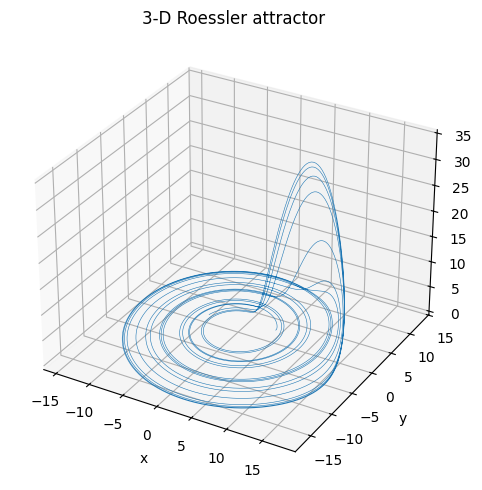

In [214]:
a, b, c = 0.15, 0.20, 10
f_roessler = lambda x, t: [-x[1] - x[2], x[0] + a * x[1], b + x[2] * (x[0] - c)]

interv_length = 100
sample_rate = 100
t_grid = np.arange(0, interv_length + 1 / sample_rate, 1 / sample_rate)
yinit = [5, 1, 1]

x_data = odeint(f_roessler, yinit, t_grid, rtol=1e-4, atol=1e-4, h0=0.5, hmax=0.5).T
print('underlying Roessler shape (3 dims, T):', x_data.shape)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x_data[0], x_data[1], x_data[2], lw=0.4)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('3-D Roessler attractor')
plt.tight_layout()
plt.show()

## 2. Generate a high-dimensional signal via `simulation_data`

`simulation_data('Roessler', ...)` integrates the same 3-D Roessler internally and then mixes it into a `Dimension`-channel signal using an internal random matrix `MixMatrix_wi`. We add a small fixed additive noise (`FixAdditiveNoise=20` dB) so the result is deterministic across runs.

In [215]:
#   N=20 channels, n=3 Roessler dims, p=17 component-noise dims,
#   FixComponentNoise=0, FixAdditiveNoise=100, SampleRate=100,
#   then downsample with step = L*dt (dt=0.5 -> every 50th sample).
N_DIM = 20              # signal dimension N
N_SIG = 3               # n - intrinsic Roessler dimensions
N_NOISE = 17            # p - component-noise dimensions
INTERV_LENGTH = 100
SAMPLE_RATE = 100
FIX_COMPONENT_NOISE = 0
FIX_ADDITIVE_NOISE = 40

# One mix matrix split into W (signal) and Psi (component noise), like MATLAB
rng = np.random.default_rng(0)
MixMatrix = rng.random((N_DIM, N_SIG + N_NOISE))   # (N, n+p)
W = MixMatrix[:, :N_SIG]                           # (N, n)
Psi = MixMatrix[:, N_SIG:]                         # (N, p)

# simulation_data expects (n, N) and (p, N) -> transpose vs MATLAB
dic = simulation_data(
    'Roessler',
    IntervLength=INTERV_LENGTH,
    SampleRate=SAMPLE_RATE,
    MixMatrix_wi=W.T,
    MixMatrix_psij=Psi.T,
    FixComponentNoise=FIX_COMPONENT_NOISE,
    FixAdditiveNoise=FIX_ADDITIVE_NOISE,
)

time_vec = dic['TimeSignal']
high_d = dic['SampleSignal']      # shape: (N_DIM, T)

print('high-D signal shape (channels, T):', high_d.shape)
print('time vector shape:', time_vec.shape)

AmplitudeNoise is not activated
ComponentNoise is not activated
AdditiveNoise is not activated
AmplitudeNoise is not activated
ComponentNoise is activated
AdditiveNoise is activated
high-D signal shape (channels, T): (20, 10001)
time vector shape: (10001,)


## 3. Inspect a few channels

The mixed channels are linear combinations of `x, y, z` from the Roessler attractor, so they all share the same chaotic dynamics but with different scales and shapes.

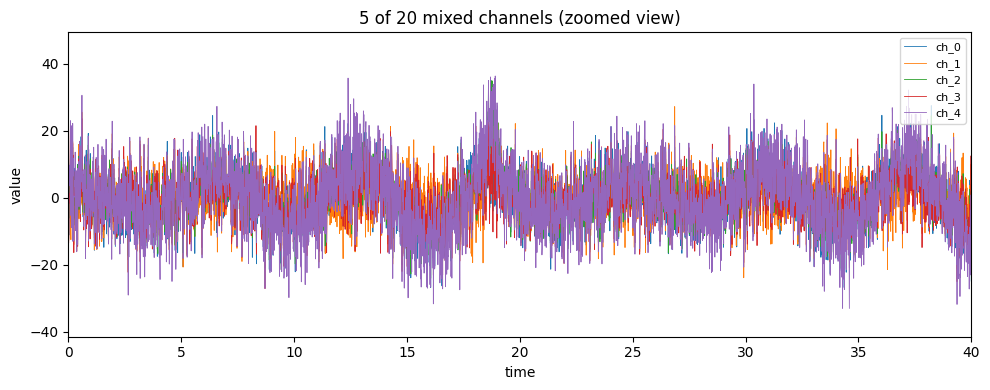

In [216]:
signal_df = pd.DataFrame(high_d.T, index=time_vec, columns=[f'ch_{i}' for i in range(N_DIM)])
signal_df.index.name = 'time'

fig, ax = plt.subplots(figsize=(10, 4))
for col in signal_df.columns[:5]:
    ax.plot(signal_df.index, signal_df[col], lw=0.6, label=col)
ax.set_xlabel('time')
ax.set_ylabel('value')
ax.set_title(f'5 of {N_DIM} mixed channels (zoomed view)')
ax.set_xlim(0, 40)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

## 4. Compute AVD on the high-dimensional signal

Mean-normalise per channel (so AVD picks up *fluctuations* rather than absolute level differences) and run `calculate_AVD_feature` for both `MAD` and `SD`. The window is roughly two Roessler quasi-periods wide.

In [217]:
W_SIZE = 200    # 200 samples = 2 time units at sample_rate=100
W_INCRE = 20

normalized = signal_df - signal_df.mean(axis=0)

avd_mad = calculate_AVD_feature(normalized, metric='MAD', w_size=W_SIZE, w_incre=W_INCRE)
avd_sd = calculate_AVD_feature(normalized, metric='SD', w_size=W_SIZE, w_incre=W_INCRE)

# map window-end indices back to actual time values
mad_time = time_vec[avd_mad.index.values]
sd_time = time_vec[avd_sd.index.values]

print(f'AVD windows: {len(avd_mad)} (MAD), {len(avd_sd)} (SD)')
avd_mad.head()

AVD windows: 491 (MAD), 491 (SD)


,MAD
Time Point,
199,0.729854
219,0.630975
239,0.615586
259,0.650867
279,0.730031


## 5. Plot AVD curves

The top panel overlays a few of the mixed channels (the input). The bottom two panels show the two AVD curves on the same time axis, so you can see which segments of the Roessler trajectory generate the largest cross-channel volatility disagreement.

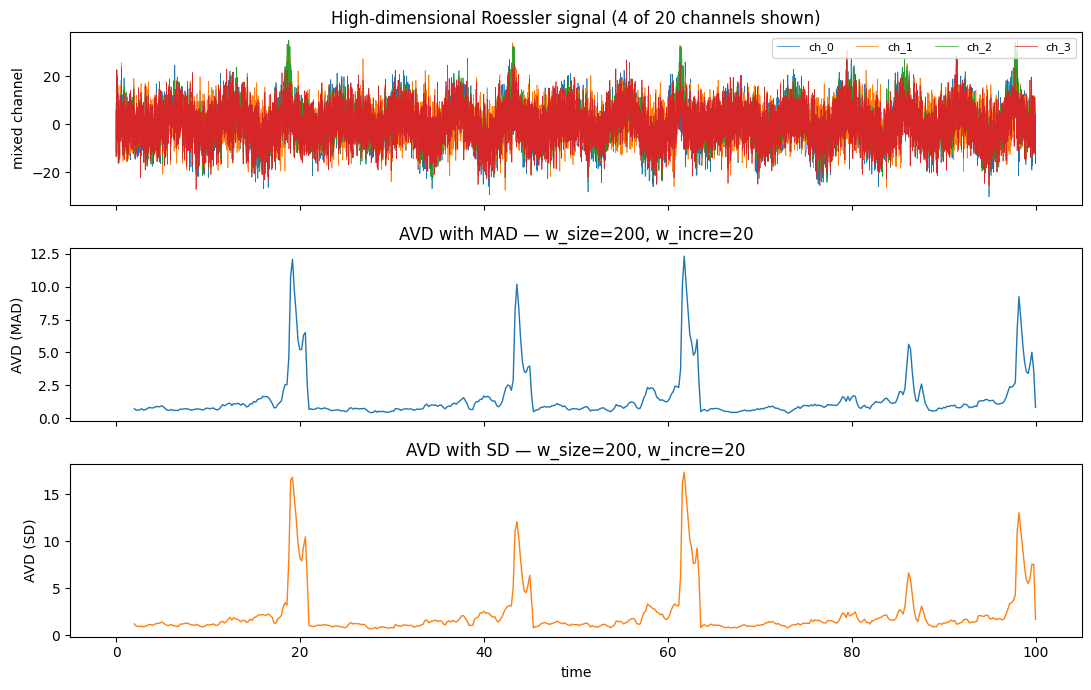

In [218]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)

for col in signal_df.columns[:4]:
    axes[0].plot(signal_df.index, signal_df[col], lw=0.5, label=col)
axes[0].set_ylabel('mixed channel')
axes[0].set_title('High-dimensional Roessler signal (4 of {N} channels shown)'.format(N=N_DIM))
axes[0].legend(loc='upper right', fontsize=8, ncol=4)

axes[1].plot(mad_time, avd_mad['MAD'].values, color='C0', lw=1.0)
axes[1].set_ylabel('AVD (MAD)')
axes[1].set_title(f'AVD with MAD — w_size={W_SIZE}, w_incre={W_INCRE}')

axes[2].plot(sd_time, avd_sd['SD'].values, color='C1', lw=1.0)
axes[2].set_ylabel('AVD (SD)')
axes[2].set_xlabel('time')
axes[2].set_title(f'AVD with SD — w_size={W_SIZE}, w_incre={W_INCRE}')

plt.tight_layout()
plt.show()

## 6. MAD vs. SD on the same axes

Same data, two volatility measures. Shapes are similar; SD-based AVD is generally larger in magnitude because squared deviations grow faster than absolute ones.

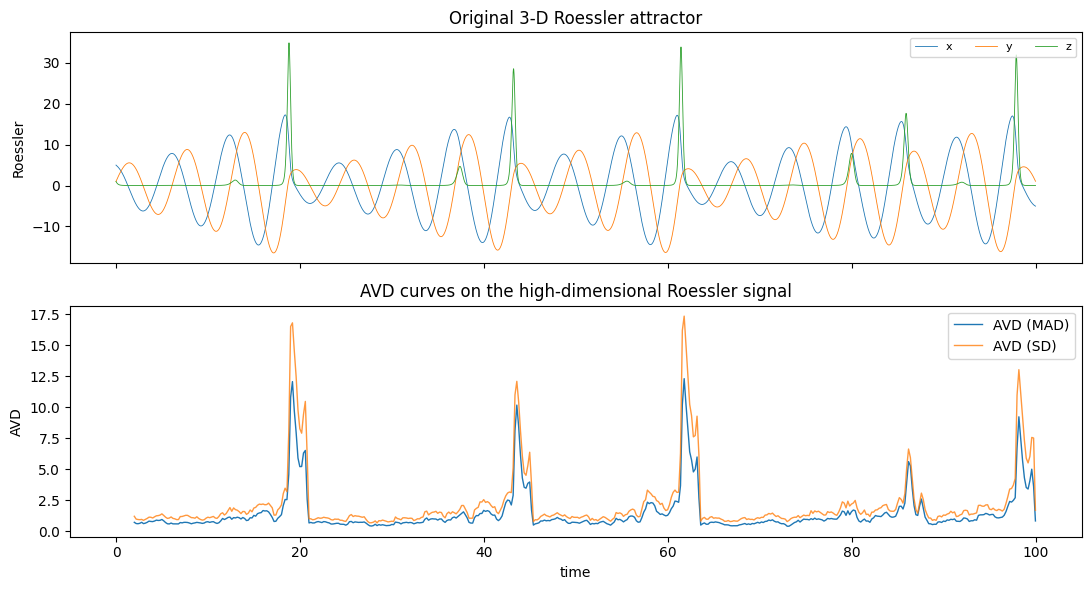

In [219]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(t_grid, x_data[0], lw=0.6, label='x')
axes[0].plot(t_grid, x_data[1], lw=0.6, label='y')
axes[0].plot(t_grid, x_data[2], lw=0.6, label='z')
axes[0].set_ylabel('Roessler')
axes[0].set_title('Original 3-D Roessler attractor')
axes[0].legend(loc='upper right', fontsize=8, ncol=3)

axes[1].plot(mad_time, avd_mad['MAD'].values, label='AVD (MAD)', lw=1.0)
axes[1].plot(sd_time, avd_sd['SD'].values, label='AVD (SD)', lw=1.0, alpha=0.8)
axes[1].set_xlabel('time')
axes[1].set_ylabel('AVD')
axes[1].set_title('AVD curves on the high-dimensional Roessler signal')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. DyCA on the same signal

[Dynamical Component Analysis (Seifert et al., 2018)](https://doi.org/10.1109/MLSP.2018.8517024) recovers a low-dimensional state from a high-dimensional mixed signal by exploiting the assumption that part of the dynamics is described by a small number of linear ODEs.

For a signal $x(t)\in\mathbb{R}^N$ assumed mean-centred, define
$$
C_0 = \langle x x^\top\rangle,\quad C_1 = \langle \dot x\, x^\top\rangle,\quad C_2 = \langle \dot x \dot x^\top\rangle.
$$
DyCA solves the generalised eigenvalue problem
$$
C_1^\top C_0^{-1} C_1\, u = \lambda\, C_2\, u,
$$
and the eigenvalues $\lambda\approx 1$ correspond to the *linear* part of the dynamics. The Roessler attractor has $\dot x = -y - z$ and $\dot y = x + a\,y$ as **linear** equations and $\dot z = b + z(x-c)$ as the single **non-linear** equation, so we expect $m = 2$ linear DEs and a total state dimension of $n = 3$.

The DyCA projection matrix is built from the $m$ top eigenvectors plus $n-m$ "derivative" directions $C_0^{-1} C_1\, v_i$.

In [220]:
# Use the published DyCA package: https://pypi.org/project/dyca/
# pip install dyca
from dyca import dyca

amplitudes shape: (3, 10001)
top 5 generalised eigenvalues: [0.3211 0.084  0.0045 0.0043 0.0029]
(values close to 1 -> linear DEs; expect ~2 of them)
singular values of projection: [1.4113 1.3875 0.2737 0.0898]


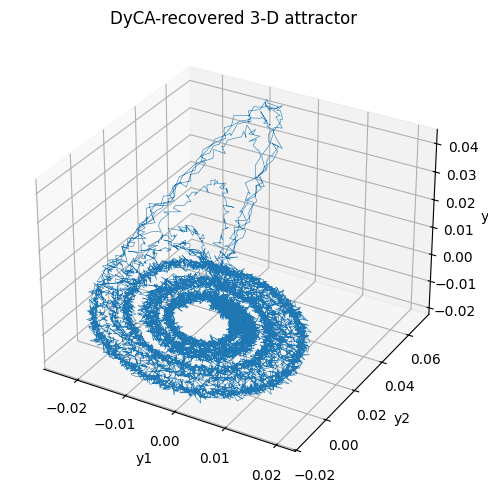

In [221]:
M_LINEAR = 2
N_TOTAL = 3

# dyca expects (time, channels)
X = normalized.values

result = dyca(X, m=M_LINEAR, n=N_TOTAL, time_index=time_vec)

Y_dyca = result['amplitudes']                        # (n, time)
gen_eigvals = result['generalized_eigenvalues']
sing_vals = result['singular_values']

print(f'amplitudes shape: {Y_dyca.shape}')
print(f'top {N_TOTAL + 2} generalised eigenvalues:', np.round(gen_eigvals[:N_TOTAL + 2], 4))
print(f'(values close to 1 -> linear DEs; expect ~{M_LINEAR} of them)')
print(f'singular values of projection: {np.round(sing_vals, 4)}')

# 3-D phase portrait of the recovered DyCA components
fig = plt.figure(figsize=(6, 5))
ax3d = fig.add_subplot(111, projection='3d')
ax3d.plot(Y_dyca[0], Y_dyca[1], Y_dyca[2], lw=0.4)
ax3d.set_xlabel('y1')
ax3d.set_ylabel('y2')
ax3d.set_zlabel('y3')
ax3d.set_title('DyCA-recovered 3-D attractor')
plt.tight_layout()
plt.show()

## 8. Compare the DyCA components with the AVD curves

The three DyCA amplitudes ($m=2$ linear + 1 nonlinear) should reveal a Roessler-like attractor in 3-D, recovered from the 20-channel mix. We plot them against the two AVD curves on the same time axis: AVD spikes mark intervals where the per-channel volatilities disagree most, which on a Roessler signal coincides with the *spiral-out* phase that ends in a `z` burst — exactly where the nonlinear DyCA component swings.

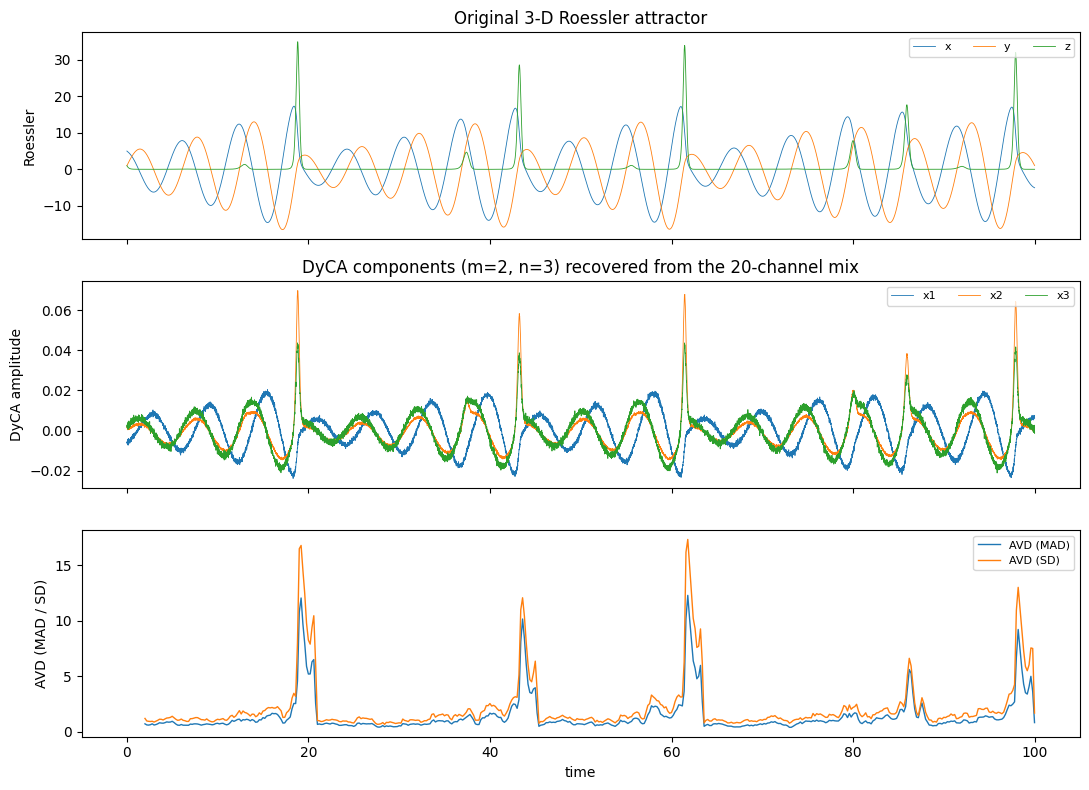

In [222]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

# 1) Underlying 3-D Roessler attractor (ground truth)
axes[0].plot(t_grid, x_data[0], lw=0.6, label='x')
axes[0].plot(t_grid, x_data[1], lw=0.6, label='y')
axes[0].plot(t_grid, x_data[2], lw=0.6, label='z')
axes[0].set_ylabel('Roessler')
axes[0].set_title('Original 3-D Roessler attractor')
axes[0].legend(loc='upper right', fontsize=8, ncol=3)

# 2) DyCA amplitudes recovered from the high-D mix
labels = [f'x{i+1}' for i in range(N_TOTAL)]
for i in range(N_TOTAL):
    axes[1].plot(time_vec, Y_dyca[i], lw=0.6, label=labels[i])
axes[1].set_ylabel('DyCA amplitude')
axes[1].set_title(f'DyCA components (m={M_LINEAR}, n={N_TOTAL}) recovered from the {N_DIM}-channel mix')
axes[1].legend(loc='upper right', fontsize=8, ncol=N_TOTAL)

# 3) AVD curves (MAD and SD) overlaid
axes[2].plot(mad_time, avd_mad['MAD'].values, color='C0', lw=1.0, label='AVD (MAD)')
axes[2].plot(sd_time, avd_sd['SD'].values, color='C1', lw=1.0, label='AVD (SD)')
axes[2].set_ylabel('AVD (MAD / SD)')
axes[2].set_xlabel('time')
axes[2].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()




## 9. PCA and DMD on the same signal

Two more dimension-reduction baselines applied to the same 20-channel mix:

- **PCA** — orthogonal directions of maximum variance. Linear, no dynamics assumption. The top three principal components capture the energetic part of the signal but do not exploit the fact that successive samples are linked by a flow.
- **DMD** (Dynamic Mode Decomposition, exact variant from Tu et al. 2014) — fits a best-fit linear operator $A$ to consecutive snapshots so $x_{k+1}\approx A x_k$. The dominant DMD modes give complex exponentials $b_i\,\lambda_i^k$ as time dynamics.

Both produce three time-courses we can line up against the DyCA amplitudes and the AVD curves.

In [223]:
from sklearn.decomposition import PCA

# PCA on the same mean-centred (time, channels) matrix
pca = PCA(n_components=N_TOTAL)
Y_pca = pca.fit_transform(X).T          # (n, time) for shape consistency with DyCA

print('PCA explained variance ratios:', np.round(pca.explained_variance_ratio_, 4))
print('PCA cumulative                :', np.round(pca.explained_variance_ratio_.cumsum(), 4))

PCA explained variance ratios: [0.7979 0.0655 0.0295]
PCA cumulative                : [0.7979 0.8634 0.8929]


In [226]:
# Use the published PyDMD package: https://pypi.org/project/pydmd/
# pip install pydmd
from pydmd import DMD
from pydmd.preprocessing import zero_mean_preprocessing

n = N_TOTAL
centered_dmd = zero_mean_preprocessing(DMD(svd_rank=n))
centered_dmd.fit(X)                                  # (channels, time)

# Use the temporal dynamics (n_modes, time) for the comparison plot.
modes_dmd = centered_dmd.modes
eigenvalues = centered_dmd.eigs

final_signals = []
processed_idx = set()

# Alle Modi durchgehen
for i in range(len(eigenvalues)):
    # Wenn der Modus ein Zwilling ist -> überspringen
    if i in processed_idx:
        continue
    
    # Wenn wir schon 4 Signale haben -> abbrechen
    if len(final_signals) >= n:
        break
        
    if abs(np.imag(eigenvalues[i])) < 1e-10:
        # Fall 1: Der Modus ist rein reell
        final_signals.append(np.real(modes_dmd[:, i]))
        processed_idx.add(i)
    else:
        # Fall 2: Der Modus ist komplex
        # Wir speichern Real- UND Imaginärteil als zwei separate Signale
        final_signals.append(np.real(modes_dmd[:, i]))
        
        if len(final_signals) < n:
            final_signals.append(np.imag(modes_dmd[:, i]))
        
        processed_idx.add(i)
        
        # Finde den unnötigen Zwilling (konjugierten Partner) und markiere ihn zum Überspringen
        for j in range(i + 1, len(eigenvalues)):
            if abs(eigenvalues[j] - np.conj(eigenvalues[i])) < 1e-5:
                processed_idx.add(j)
                break

final_signals_array = np.column_stack(final_signals)
Y_dmd = np.array(final_signals_array)                        # (n, time)

dt = 1.0 / SAMPLE_RATE
print('DMD eigenvalues       :', np.round(eigenvalues, 4))
print('DMD frequencies (Hz)  :', np.round(np.angle(eigenvalues) / (2 * np.pi * dt), 4))
print('DMD growth rates      :', np.round(np.log(np.abs(eigenvalues)) / dt, 4))
print('Y_dmd shape           :', Y_dmd.shape)

DMD eigenvalues       : [ 0.9892 -0.6593  0.0905]
DMD frequencies (Hz)  : [ 0. 50.  0.]
DMD growth rates      : [  -1.0899  -41.6568 -240.2199]
Y_dmd shape           : (10001, 3)


## 10. Side-by-side comparison

Five panels on the same time axis:

1. Original 3-D Roessler (ground truth).
2. DyCA amplitudes (the dynamics-aware method).
3. PCA components (variance-only baseline).
4. DMD time-modes (linear-flow-fitted baseline).
5. AVD-MAD and AVD-SD curves.

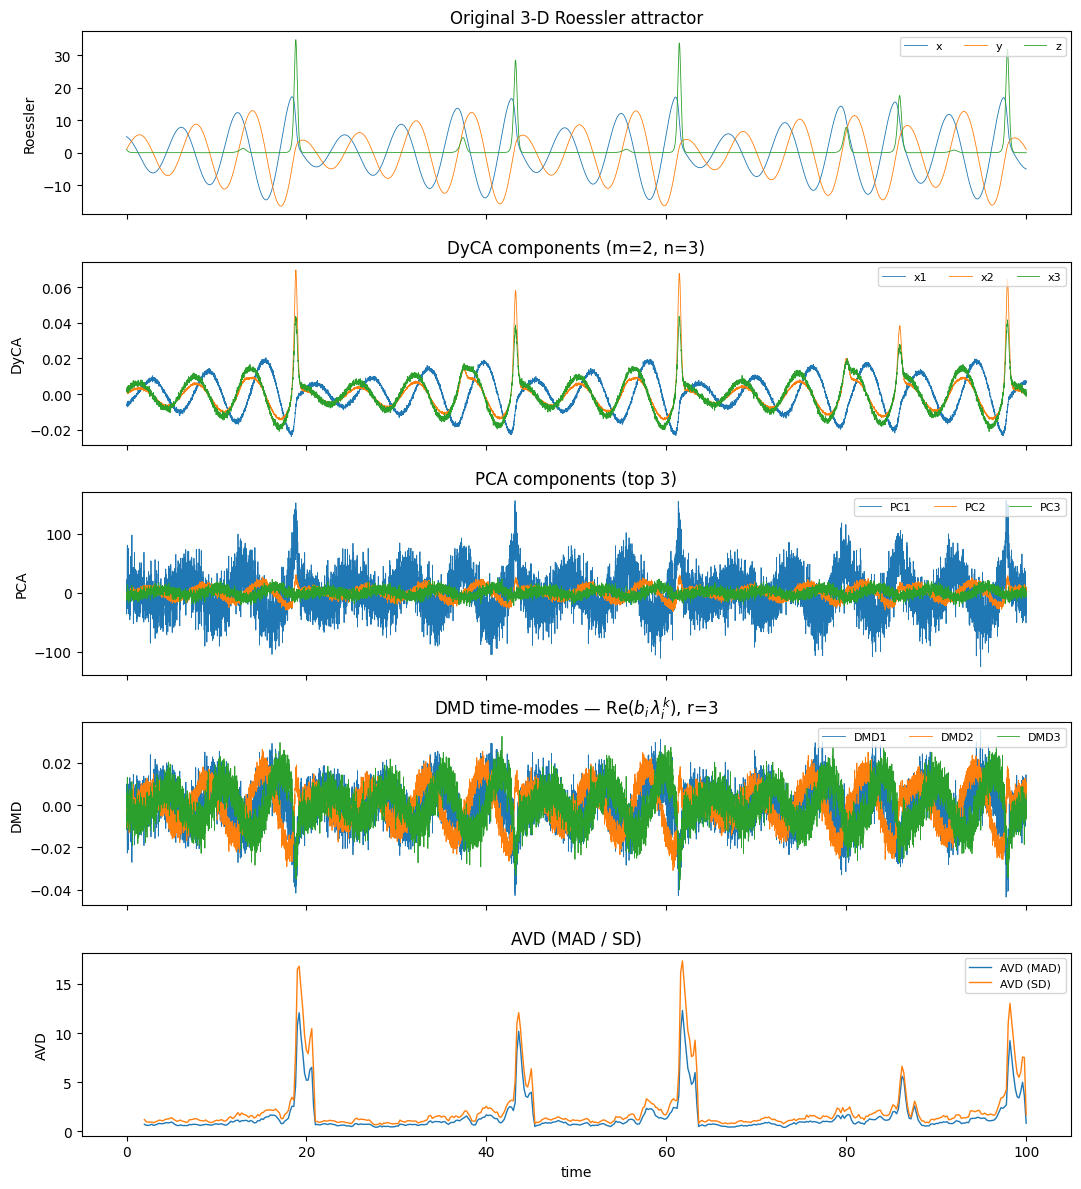

In [227]:
fig, axes = plt.subplots(5, 1, figsize=(11, 12), sharex=True)

# 1) Underlying 3-D Roessler (ground truth)
axes[0].plot(t_grid, x_data[0], lw=0.6, label='x')
axes[0].plot(t_grid, x_data[1], lw=0.6, label='y')
axes[0].plot(t_grid, x_data[2], lw=0.6, label='z')
axes[0].set_ylabel('Roessler')
axes[0].set_title('Original 3-D Roessler attractor')
axes[0].legend(loc='upper right', fontsize=8, ncol=3)

# 2) DyCA
for i in range(N_TOTAL):
    axes[1].plot(time_vec, Y_dyca[i], lw=0.6, label=f'x{i+1}')
axes[1].set_ylabel('DyCA')
axes[1].set_title(f'DyCA components (m={M_LINEAR}, n={N_TOTAL})')
axes[1].legend(loc='upper right', fontsize=8, ncol=N_TOTAL)

# 3) PCA
for i in range(N_TOTAL):
    axes[2].plot(time_vec, Y_pca[i], lw=0.6, label=f'PC{i+1}')
axes[2].set_ylabel('PCA')
axes[2].set_title(f'PCA components (top {N_TOTAL})')
axes[2].legend(loc='upper right', fontsize=8, ncol=N_TOTAL)

# 4) DMD (real part of the dominant time-modes)
for i in range(N_TOTAL):
    axes[3].plot(time_vec, Y_dmd[:, i], lw=0.6, label=f'DMD{i+1}')
axes[3].set_ylabel('DMD')
axes[3].set_title(f'DMD time-modes — Re($b_i\\,\\lambda_i^k$), r={N_TOTAL}')
axes[3].legend(loc='upper right', fontsize=8, ncol=N_TOTAL)

# 5) AVD curves
axes[4].plot(mad_time, avd_mad['MAD'].values, color='C0', lw=1.0, label='AVD (MAD)')
axes[4].plot(sd_time, avd_sd['SD'].values, color='C1', lw=1.0, label='AVD (SD)')
axes[4].set_ylabel('AVD')
axes[4].set_xlabel('time')
axes[4].set_title('AVD (MAD / SD)')
axes[4].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()